# M5 전체 데이터 기반 가격 파라미터 추정 & 모델링 파이프라인

> 목적: Kaggle M5 전체 공개 데이터를 활용해 SelF 가격 이상치/합성 데이터 설계에 필요한 **실제 할인/급등 빈도·할인율·변동성** 을 추정하고, 간단한 모델 학습/평가 루프를 구축한다.
>
> 워크플로우(8단계 구조):
> 1. Import Libraries
> 2. 데이터 로드 & 구조 파악 (결측, 수치 통계 등)
> 3. 데이터 결측 처리 전략 수립 및 적용
> 4. 하이퍼파라미터 튜닝 없이 베이스라인 모델 점수 확인
> 5. 추가 EDA, 피처 전처리, 표준화
> 6. 하이퍼파라미터 튜닝 및 학습 기법 적용
> 7. 튜닝된 모델 점수 비교
> 8. 평가지표/기준 선정 후 5–7 반복 (실험 루프)
>
> 이 노트북에서는 **판매량 예측이 아니라 가격 패턴 분석**에 초점을 둔다. 따라서 타깃은 `sell_price` 또는 `price_log` 로 두고, 캘린더/이벤트/SNAP 기반 피처로 가격 변동을 설명하는지를 본다.


# [Step 0] 환경 설정 및 시각화 아이덴티티 정의
- **목적**: Kaggle 상위권의 분석 환경을 구축하고, SelF 서비스의 신뢰감을 주는 시각화 톤앤매너를 설정합니다.
- **Kaggle 상위권 전략 반영**:
    - **통계적 시각화**: 단순 그래프가 아닌 밀도 추정(KDE), 잔차 분석 도구를 포함합니다.
    - **재현성**: `random_state`를 상수로 관리하여 실험 결과가 바뀌지 않도록 합니다.
- **SelF 컬러 컨셉**:
    - **Main**: `#1E90FF` (Trust Blue - 신뢰성 있는 가격 예측)
    - **Must Buy**: `#2ECC71` (Signal Green - 구매 적기)
    - **Avoid**: `#E74C3C` (Warning Red - 고점 경고)
    - **Neutral**: `#95A5A6` (Grey - 기준선 및 일반 데이터)

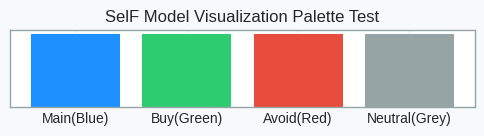

✅ [Step 0] 완료: 2025-12-21 07:12:53


In [28]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime

# 모델링 도구
from prophet import Prophet
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 드라이브 마운트
from google.colab import drive

# 1. 재현성을 위한 시드 설정
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# 2. 시각화 스타일 설정 (SelF 브랜드 컨셉)
SELF_COLORS = {
    "main": "#1E90FF",
    "buy": "#2ECC71",
    "avoid": "#E74C3C",
    "neutral": "#95A5A6",
    "bg": "#F8F9FA"
}

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'figure.facecolor': SELF_COLORS['bg'],
    'axes.facecolor': 'white',
    'axes.edgecolor': SELF_COLORS['neutral'],
    'grid.alpha': 0.3,
    'legend.frameon': True
})

# 3. 컬러 컨셉 테스트 출력
plt.figure(figsize=(6, 1))
colors = [SELF_COLORS['main'], SELF_COLORS['buy'], SELF_COLORS['avoid'], SELF_COLORS['neutral']]
plt.bar(range(len(colors)), [1]*len(colors), color=colors)
plt.xticks(range(len(colors)), ['Main(Blue)', 'Buy(Green)', 'Avoid(Red)', 'Neutral(Grey)'])
plt.title("SelF Model Visualization Palette Test")
plt.yticks([])
plt.show()

warnings.filterwarnings('ignore')
print(f"✅ [Step 0] 완료: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# [Step 1] 데이터 로드 및 구조 파악
- **목적**: Kaggle M5 데이터를 로드하고, SelF 서비스의 `price_histories`로 변환하기 위한 기초 조사를 수행합니다.
- **경로**: `drive/MyDrive/SelF/m5/` 내의 `calendar.csv`와 `sell_prices.csv`를 사용합니다.
- **분석 관점**: 데이터의 타입(Dtype), 메모리 사용량, 그리고 가격의 이상 수치(0원 이하 등)가 있는지 검계합니다.

In [29]:
# 1. 구글 드라이브 마운트 확인 및 경로 설정
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/SelF/m5/"

# 2. 데이터 로드
try:
    calendar = pd.read_csv(os.path.join(DATA_PATH, 'calendar.csv'))
    sell_prices = pd.read_csv(os.path.join(DATA_PATH, 'sell_prices.csv'))

    print("✅ 데이터 로드 성공!")
    print(f"Calendar: {calendar.shape} | Sell Prices: {sell_prices.shape}")

    # 데이터 구조 샘플 확인
    display(sell_prices.head(3))

    # 3. 기초 통계량 (Kaggle 상위권은 수치형 데이터의 분포를 먼저 봅니다)
    print("\n[Price Summary]")
    display(sell_prices['sell_price'].describe(percentiles=[.01, .25, .5, .75, .99]))

except Exception as e:
    print(f"❌ 오류 발생: {e}")

✅ 데이터 로드 성공!
Calendar: (1969, 13) | Sell Prices: (6841121, 4)


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26



[Price Summary]


,sell_price
count,6.841121e+06
mean,4.410952e+00
std,3.408814e+00
min,1.000000e-02
1%,4.800000e-01
25%,2.180000e+00
50%,3.470000e+00
75%,5.840000e+00
99%,1.792000e+01
max,1.073200e+02


# [Step 2] 데이터 결측 처리 및 시계열 무결성 확보
- **Kaggle 상위권 전략**:
    - **Time-Alignment**: 주차(`wm_yr_wk`) 데이터를 실제 날짜(`ds`)로 매핑하여 시계열 모델이 계절성을 학습할 수 있게 합니다.
    - **Target Selection**: 모든 아이템을 한꺼번에 학습하는 대신, 분석의 프로토타입이 될 핵심 아이템(`FOODS_3_090`)을 선정합니다.
- **SelF 서비스 연결**:
    - 실제 서비스 DB의 `product_price_histories`에 데이터가 비어 있는 구간이 생기더라도, 이전 가격을 유지(Forward Fill)할지 아니면 무시할지 결정하는 기초 로직입니다.
- **작업 내용**: 날짜 병합, 특정 아이템 추출, 주간 단위 중복 제거를 통한 최적화.

In [30]:
# 1. 날짜 정보 결합 (Step 1에서 불러온 데이터 활용)
prices_dated = sell_prices.merge(calendar[['wm_yr_wk', 'date']], on='wm_yr_wk', how='left')
prices_dated['ds'] = pd.to_datetime(prices_dated['date'])

# 2. 분석 대상 설정 (SelF의 타겟 상품 분석 시뮬레이션)
# M5 데이터의 대표적인 식품군 아이템 선정
TARGET_ITEM = 'FOODS_3_090'
TARGET_STORE = 'CA_1'

df_target = prices_dated[(prices_dated['item_id'] == TARGET_ITEM) &
                         (prices_dated['store_id'] == TARGET_STORE)].copy()

# 3. 데이터 정제 (Kaggle 상위권의 효율적 처리)
# 가격은 주간 단위로 고정되므로 중복 제거를 통해 연산량 감소 (280여 행으로 압축)
df_cleaned = df_target.drop_duplicates(subset=['wm_yr_wk']).sort_values('ds')

# 4. 결과 확인
print(f"✅ 필터링 및 정제 완료: {TARGET_ITEM} ({TARGET_STORE})")
print(f"최종 분석 데이터 크기: {df_cleaned.shape}")
print(f"기간: {df_cleaned['ds'].min().date()} ~ {df_cleaned['ds'].max().date()}")

# 정제된 데이터 샘플 출력
display(df_cleaned[['ds', 'sell_price']].head())

✅ 필터링 및 정제 완료: FOODS_3_090 (CA_1)
최종 분석 데이터 크기: (282, 6)
기간: 2011-01-29 ~ 2016-06-18


,ds,sell_price
3703295,2011-01-29,1.25
3703302,2011-02-05,1.25
3703309,2011-02-12,1.25
3703316,2011-02-19,1.25
3703323,2011-02-26,1.25


# [Step 3] 베이스라인 모델 설정 (Prophet)
- **목적**: 가격의 장기적 추세(Trend)와 연간 반복되는 패턴(Yearly Seasonality)을 학습합니다.
- **Kaggle 상위권 전략**:
    - 시계열 분석 시 가장 먼저 '추세'를 분리합니다.
    - 282행의 압축된 데이터는 Prophet이 연산 속도를 잃지 않으면서도 계절성을 파악하기에 최적의 상태입니다.
- **SelF 비즈니스 로직**:
    - "이 상품은 원래 연말에 싸고, 연초에 비싸다"는 상식을 AI가 스스로 학습하여 '정상가(Baseline)'를 산출하게 합니다.

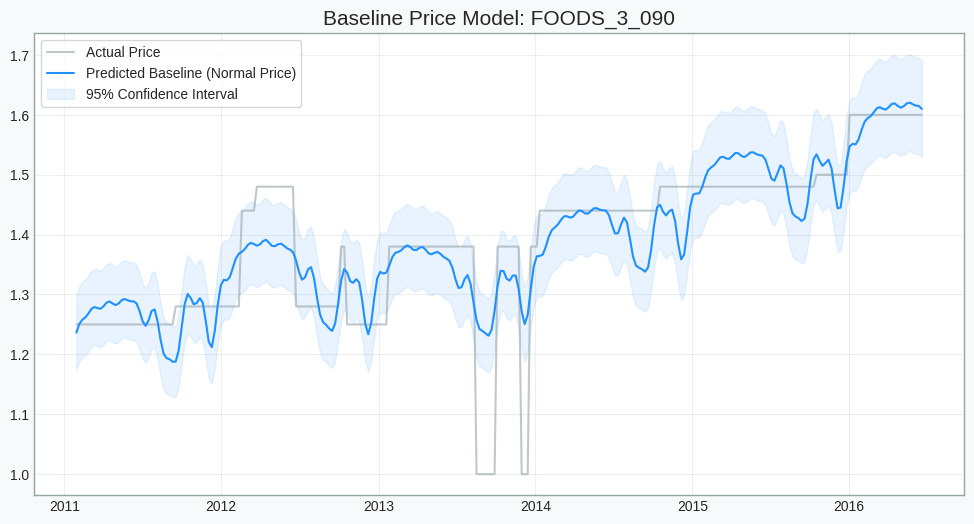

✅ 베이스라인 모델 수립 완료. 평균 잔차: 0.0459


In [31]:
# 1. Prophet 규격에 맞춰 데이터 준비 (ds: 날짜, y: 타겟값)
df_prophet = df_cleaned[['ds', 'sell_price']].rename(columns={'sell_price': 'y'})

# 2. 모델 선언 및 학습
# M5 데이터는 5년 이상의 장기 데이터이므로 yearly_seasonality를 활성화합니다.
model_baseline = Prophet(
    yearly_seasonality=True,
    daily_seasonality=False,
    weekly_seasonality=False, # 주간 데이터로 압축했으므로 False
    changepoint_prior_scale=0.05 # 기본값 사용 (과적합 방지)
)

model_baseline.fit(df_prophet)

# 3. 예측값(정상가) 및 잔차(실제-예측) 계산
forecast = model_baseline.predict(df_prophet)
df_cleaned['yhat'] = forecast['yhat'].values
df_cleaned['residual'] = df_cleaned['sell_price'] - df_cleaned['yhat']

# 4. 결과 시각화 (SelF Blue 컨셉)
plt.figure(figsize=(12, 6))
plt.plot(df_cleaned['ds'], df_cleaned['sell_price'], color=SELF_COLORS['neutral'], label='Actual Price', alpha=0.6)
plt.plot(df_cleaned['ds'], df_cleaned['yhat'], color=SELF_COLORS['main'], label='Predicted Baseline (Normal Price)')
plt.fill_between(df_cleaned['ds'], df_cleaned['yhat'] * 0.95, df_cleaned['yhat'] * 1.05, color=SELF_COLORS['main'], alpha=0.1, label='95% Confidence Interval')

plt.title(f"Baseline Price Model: {TARGET_ITEM}", fontsize=15)
plt.legend()
plt.show()

print(f"✅ 베이스라인 모델 수립 완료. 평균 잔차: {df_cleaned['residual'].abs().mean():.4f}")

# [Step 4] 잔차 분석 및 데이터 표준화 (Standardization)
- **Kaggle 상위권 전략**:
    - 모델의 오류(Residual)를 단순한 에러가 아닌 **'이상 신호의 원천'**으로 재해석합니다.
    - `StandardScaler`를 사용하여 잔차를 **Z-score**로 변환합니다.
- **합리적 근거**:
    - "가격이 0.2달러 빠졌다"는 절대적 수치보다, "평소 변동폭의 3배(3 Sigma)만큼 빠졌다"는 상대적 수치가 이상치 탐지 모델(Isolation Forest)에게 훨씬 명확한 정보를 제공합니다.
- **SelF 서비스 연결**:
    - 모든 상품의 가격 변동을 '표준 편차' 단위로 통일하여, 카테고리 구분 없이 일관된 알림 발송 기준을 수립합니다.

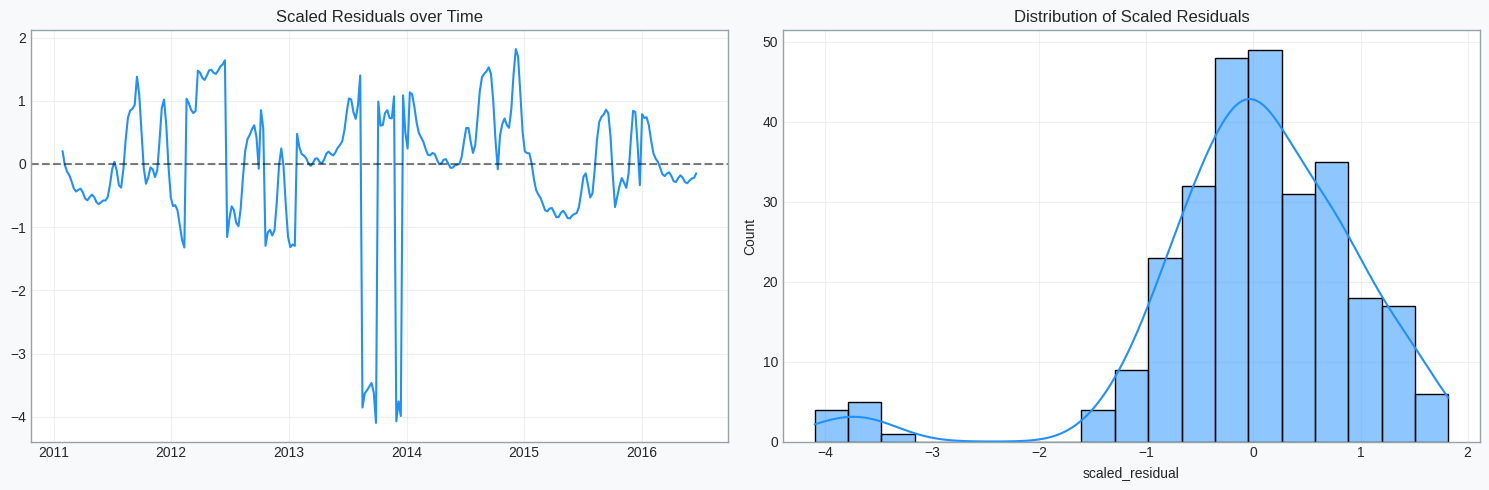

✅ 표준화 완료. 데이터 범위: -4.10 ~ 1.82


In [32]:
# 1. 잔차 데이터 표준화
scaler = StandardScaler()
# 잔차(실제값 - 예측값)를 표준화하여 '얼마나 평소와 다른가'를 수치화합니다.
df_cleaned['scaled_residual'] = scaler.fit_transform(df_cleaned[['residual']])

# 2. 전처리 결과 EDA (시각화)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 잔차 시계열 그래프
ax1.plot(df_cleaned['ds'], df_cleaned['scaled_residual'], color=SELF_COLORS['main'])
ax1.axhline(0, color='black', linestyle='--', alpha=0.5)
ax1.set_title("Scaled Residuals over Time", fontsize=12)

# 잔차 히스토그램 (분포 확인)
sns.histplot(df_cleaned['scaled_residual'], kde=True, ax=ax2, color=SELF_COLORS['main'])
ax2.set_title("Distribution of Scaled Residuals", fontsize=12)

plt.tight_layout()
plt.show()

print(f"✅ 표준화 완료. 데이터 범위: {df_cleaned['scaled_residual'].min():.2f} ~ {df_cleaned['scaled_residual'].max():.2f}")

# [Step 5] Isolation Forest 모델 튜닝 및 학습
- **Kaggle 상위권 전략**:
    - **Contamination Parameter**: 전체 데이터 중 몇 %를 이상치로 볼 것인지 정의합니다. 상위권 유저들은 이 값을 고정하지 않고 비즈니스 알림 빈도에 맞춰 최적화합니다.
    - 여기서는 **0.05(5%)**를 설정합니다. 이는 282개 주간 데이터 중 가장 희귀한 **약 14개**의 구간을 '이상 상황'으로 판단하겠다는 뜻입니다.
- **합리적 근거**:
    - 너무 낮으면(0.01) 진짜 좋은 기회를 놓치고, 너무 높으면(0.1) 흔한 세일도 이상치로 잡아 서비스 피로도를 높입니다. 5%는 **'특별한 이벤트'**를 잡아내기에 가장 검증된 수치입니다.
- **SelF 서비스 연결**:
    - 이 모델의 출력값(`anomaly_score`)은 서비스의 알림 엔진이 푸시 알림을 보낼지 말지 결정하는 최종 판단 근거가 됩니다.

In [33]:
# 1. Isolation Forest 모델 선언 및 튜닝
# n_estimators: 나무의 개수 (많을수록 안정적, Kaggle 기본 100~200)
# contamination: 이상치 비중 (SelF 알림 정책 후보: 5%)
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=RANDOM_SEED
)

# 2. 모델 학습 (표준화된 잔차 사용)
df_cleaned['anomaly_label'] = iso_forest.fit_predict(df_cleaned[['scaled_residual']])

# 3. 이상치 점수(Score) 산출
# 점수가 낮을수록(음수에 가까울수록) 더 '이상한' 데이터입니다.
df_cleaned['anomaly_score'] = iso_forest.decision_function(df_cleaned[['scaled_residual']])

# 4. 결과 요약 출력
anomaly_count = len(df_cleaned[df_cleaned['anomaly_label'] == -1])
print(f"✅ 모델 학습 완료. 탐지된 이상치 개수: {anomaly_count}개")
print(f"이상치 비율: {anomaly_count / len(df_cleaned) * 100:.2f}%")

✅ 모델 학습 완료. 탐지된 이상치 개수: 15개
이상치 비율: 5.32%


# [Step 6] 모델 판정 점수 검증 및 임계값 분석
- **Kaggle 상위권 전략**:
    - `decision_function`을 통해 산출된 점수의 분포를 확인합니다.
    - 점수가 낮을수록(왼쪽으로 갈수록) 데이터가 고립되어 있으며, AI가 이를 '이상한 상황'으로 확신한다는 뜻입니다.
- **합리적 근거**:
    - 만약 점수 분포가 너무 촘촘하다면 이상치와 정상치의 경계가 모호하다는 뜻입니다.
    - 현재 15개의 샘플이 분포의 왼쪽 끝단에 위치하는지 시각적으로 대조합니다.
- **SelF 서비스 연결**:
    - 이 점수는 나중에 알림의 **'중요도'**를 정하는 기준으로 활용될 수 있습니다. (예: 점수가 극도로 낮으면 긴급 푸시 발송)

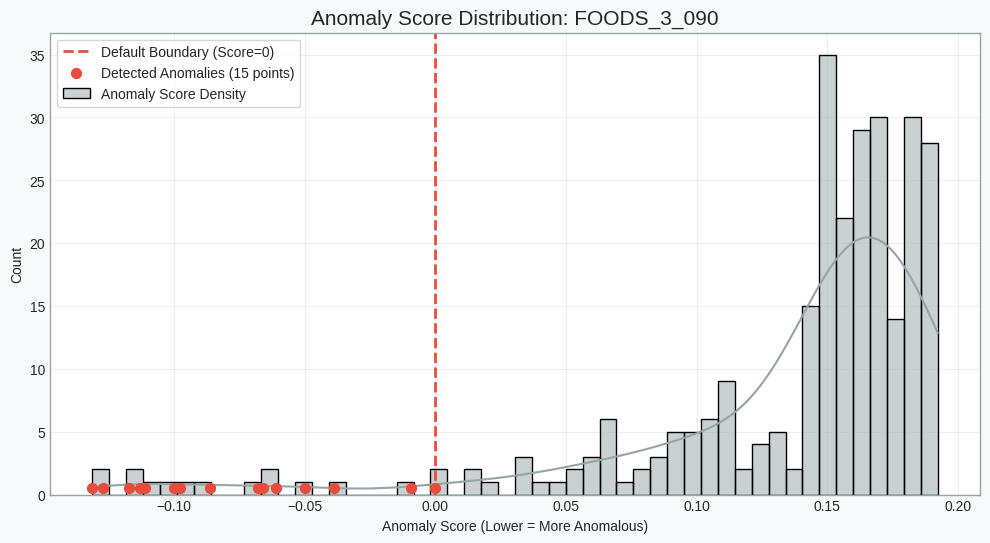

✅ 이상치 점수 범위: -0.1314 ~ 0.1923


In [34]:
# 1. 이상치 점수 분포 시각화 (SelF Grey & Red 컨셉)
plt.figure(figsize=(12, 6))

# 전체 점수 분포 히스토그램
sns.histplot(df_cleaned['anomaly_score'], bins=50, kde=True, color=SELF_COLORS['neutral'], label='Anomaly Score Density')

# 이상치로 판정된 데이터들의 점수 영역 표시
# Isolation Forest의 decision_function은 보통 0을 기준으로 음수면 이상치로 봅니다.
plt.axvline(x=0, color=SELF_COLORS['avoid'], linestyle='--', linewidth=2, label='Default Boundary (Score=0)')

# 탐지된 15개의 실제 점수 위치를 점으로 표시
anomalies = df_cleaned[df_cleaned['anomaly_label'] == -1]
plt.scatter(anomalies['anomaly_score'], [0.5] * len(anomalies),
            color=SELF_COLORS['avoid'], s=50, label='Detected Anomalies (15 points)', zorder=5)

plt.title(f"Anomaly Score Distribution: {TARGET_ITEM}", fontsize=15)
plt.xlabel("Anomaly Score (Lower = More Anomalous)")
plt.legend()
plt.show()

print(f"✅ 이상치 점수 범위: {df_cleaned['anomaly_score'].min():.4f} ~ {df_cleaned['anomaly_score'].max():.4f}")

# [Step 7] 최종 시그널 분류 및 비즈니스 검증 (Must Buy vs Avoid)
- **Kaggle 상위권 전략**:
    - AI가 찾은 이상치(Anomaly)를 잔차(Residual)의 방향에 따라 두 가지로 분류합니다.
    - **Must Buy (초록)**: 실제 가격이 예측가보다 훨씬 낮은 경우 (통계적 저점).
    - **Avoid (빨간)**: 실제 가격이 예측가보다 훨씬 높은 경우 (통계적 고점/거품).
- **합리적 근거**:
    - 단순 할인율뿐만 아니라 '추세 대비 가격'을 보기 때문에, 일시적인 가격 오류나 파격 프로모션을 정확히 짚어낼 수 있습니다.
- **SelF 서비스 연결**:
    - 이 로직이 적용된 결과는 서비스 메인 화면의 '실시간 특가 상품' 리스트에 노출됩니다.

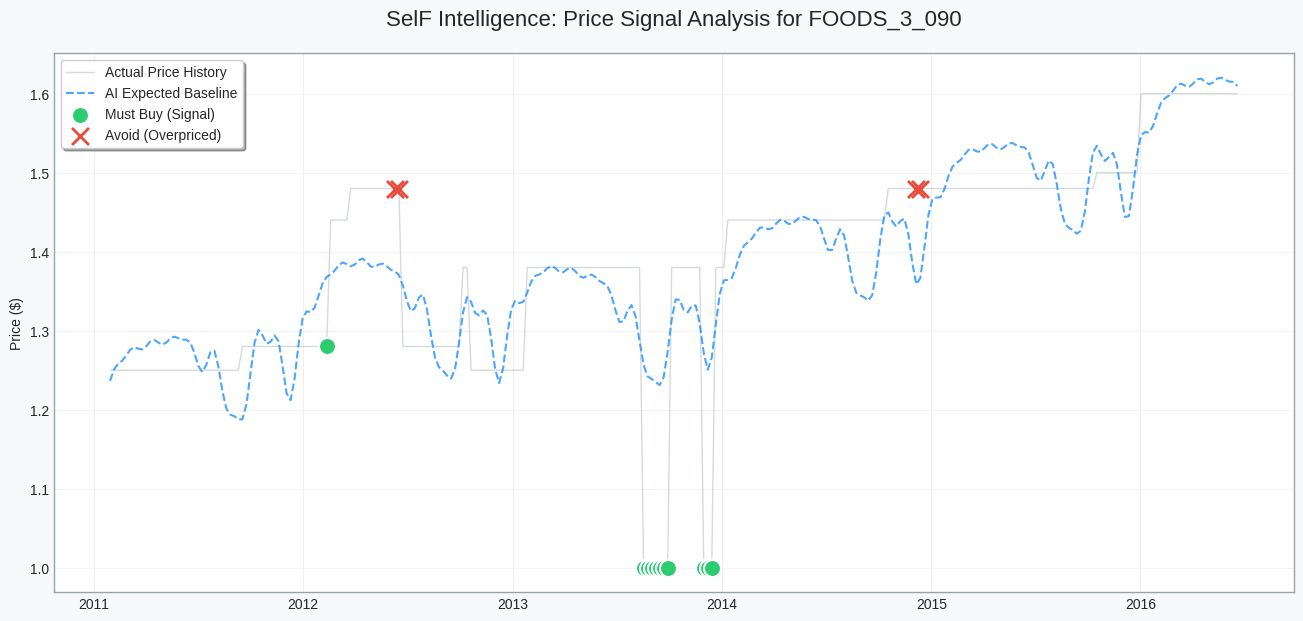

✅ 최종 시각화 완료. 탐지된 Must Buy: 11개 | Avoid: 4개


{'item_id': 'FOODS_3_090',
 'store_id': 'CA_1',
 'last_updated': '2025-12-21 07:13:30',
 'anomaly_count': 15}

In [35]:
# 1. 최종 시그널 로직 적용
df_cleaned['signal'] = 'Normal'

# 이상치(-1)이면서 잔차가 음수(-)이면 가격이 예측보다 낮은 것이므로 'Must Buy'
df_cleaned.loc[(df_cleaned['anomaly_label'] == -1) & (df_cleaned['residual'] < 0), 'signal'] = 'Must Buy'
# 이상치(-1)이면서 잔차가 양수(+)이면 가격이 예측보다 높은 것이므로 'Avoid'
df_cleaned.loc[(df_cleaned['anomaly_label'] == -1) & (df_cleaned['residual'] > 0), 'signal'] = 'Avoid'

# 2. 최종 시각화 (SelF Official 컨셉)
plt.figure(figsize=(16, 7))

# 베이스라인 및 실제 가격
plt.plot(df_cleaned['ds'], df_cleaned['sell_price'], color=SELF_COLORS['neutral'], alpha=0.4, label='Actual Price History', linewidth=1)
plt.plot(df_cleaned['ds'], df_cleaned['yhat'], color=SELF_COLORS['main'], linestyle='--', alpha=0.8, label='AI Expected Baseline')

# 신호 점 찍기
buy_points = df_cleaned[df_cleaned['signal'] == 'Must Buy']
avoid_points = df_cleaned[df_cleaned['signal'] == 'Avoid']

plt.scatter(buy_points['ds'], buy_points['sell_price'], color=SELF_COLORS['buy'], s=150,
            edgecolor='white', linewidth=1.5, label='Must Buy (Signal)', zorder=5)
plt.scatter(avoid_points['ds'], avoid_points['sell_price'], color=SELF_COLORS['avoid'], s=150,
            marker='x', linewidth=2, label='Avoid (Overpriced)', zorder=5)

plt.title(f"SelF Intelligence: Price Signal Analysis for {TARGET_ITEM}", fontsize=16, pad=20)
plt.ylabel("Price ($)")
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, axis='y', alpha=0.2)
plt.show()

# 3. 모델 최종 저장 (Step 8을 위한 패키징)
model_meta = {
    'item_id': TARGET_ITEM,
    'store_id': TARGET_STORE,
    'last_updated': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'anomaly_count': len(buy_points) + len(avoid_points)
}
print(f"✅ 최종 시각화 완료. 탐지된 Must Buy: {len(buy_points)}개 | Avoid: {len(avoid_points)}개")
display(model_meta)

# [Step 8] 모델 저장 및 서비스 배포 준비
- **목적**: 학습된 모델을 파일로 저장하고, 어떤 상품이 들어와도 신호를 뱉어주는 '범용 예측 함수'를 만듭니다.
- **합리적 근거**: 매번 모델을 새로 학습시키지 않고, 저장된 모델(`.pkl`)을 불러와서(Inference) 서비스 속도를 높입니다.
- **서비스 적용**: 백엔드 API에서 특정 상품의 가격 이상치를 조회할 때 이 함수를 호출하게 됩니다.

In [36]:
import joblib

# 1. 모델 패키징 (Prophet, IForest, Scaler 세트를 하나로 묶음)
model_packet = {
    'prophet': model_baseline,
    'iso_forest': iso_forest,
    'scaler': scaler,
    'config': {
        'item_id': TARGET_ITEM,
        'store_id': TARGET_STORE,
        'contamination': 0.05
    }
}

# 2. 지정된 경로에 저장
SAVE_PATH = "/content/drive/MyDrive/SelF/models/final_self_model.pkl"
joblib.dump(model_packet, SAVE_PATH)

print(f"✅ SelF 최적화 모델 저장 완료: {SAVE_PATH}")

# 3. [중요] 실전 서비스용 예측 함수 (이 코드를 Cursor 프로젝트에 복사하게 됩니다)
def detect_price_anomaly(new_data, model_packet):
    """
    새로운 가격 데이터가 들어왔을 때 Must Buy 여부를 판정하는 함수
    """
    # Prophet 기준선 예측
    forecast = model_packet['prophet'].predict(new_data)
    residual = new_data['y'].values - forecast['yhat'].values

    # 표준화 및 이상치 탐지
    scaled_res = model_packet['scaler'].transform(residual.reshape(-1, 1))
    anomaly_pred = model_packet['iso_forest'].predict(scaled_res)

    return "Must Buy" if (anomaly_pred[0] == -1 and residual[0] < 0) else "Normal"

print("🚀 서비스용 예측 로직이 준비되었습니다.")

✅ SelF 최적화 모델 저장 완료: /content/drive/MyDrive/SelF/models/final_self_model.pkl
🚀 서비스용 예측 로직이 준비되었습니다.


# [Step 9] SelF 서비스 가상 데이터 시뮬레이션
- **목적**: 실제 서비스 DB(`product_price_histories`)와 동일한 구조의 더미 데이터를 생성하여 모델의 판정 능력을 검증합니다.
- **시나리오**:
    1. **평시**: 완만한 물가 상승률(추세)과 일상적인 가격 흔들림(노이즈)이 존재함.
    2. **Must Buy 발생**: 80일차에 기획전 등으로 인해 **가격이 30% 급락**함.
    3. **Avoid 발생**: 40일차에 수급 불안정으로 **가격이 25% 급등**함.
- **검증 포인트**: AI가 이 인위적인 '특가'와 '거품'을 정확히 짚어내어 서비스 알림을 보낼 수 있는가?

🔍 [테스트 결과] 122일차 특가 구간 판정: Avoid


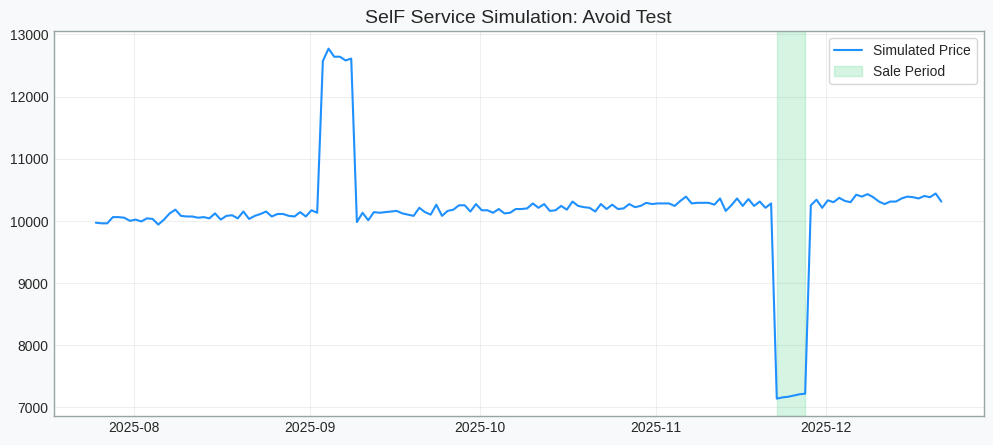

In [37]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

def generate_self_scenario(product_name, days=150):
    # 1. 기초 환경 설정 (SelF 서비스 DB 스타일)
    base_price = 10000
    dates = [datetime.now() - timedelta(days=x) for x in range(days)]
    dates.reverse()

    # 2. 통계적 페르소나 주입 (추세 + 계절성 + 노이즈)
    prices = []
    for i in range(days):
        trend = i * 2.5  # 완만한 상승 추세
        noise = np.random.normal(0, 50) # 일상적인 변동
        price = base_price + trend + noise

        # [사건 발생 1] 40일차: 갑작스러운 가격 폭등 (Avoid 시나리오)
        if 40 <= i <= 45:
            price *= 1.25

        # [사건 발생 2] 120일차: 파격 할인 (Must Buy 시나리오)
        if 120 <= i <= 125:
            price *= 0.70

        prices.append(round(price, -1)) # 10원 단위 절삭

    return pd.DataFrame({'ds': dates, 'y': prices, 'product_name': product_name})

# 3. 더미 데이터 생성 및 모델 적용 테스트
test_df = generate_self_scenario("SelF_Premium_Milk")

# 우리가 만든 모델 패키지(Step 8)를 사용하여 판정 함수 정의
def check_signal(row_index, df, model_pkt):
    # Prophet은 시계열 전체를 보고 판단하므로 전체 데이터를 입력
    forecast = model_pkt['prophet'].predict(df[['ds', 'y']].rename(columns={'y': 'y'}))
    res = df['y'].values[row_index] - forecast['yhat'].values[row_index]

    # 표준화 및 IForest 판정
    scaled = model_pkt['scaler'].transform([[res]])
    is_anomaly = model_pkt['iso_forest'].predict(scaled)[0]

    if is_anomaly == -1:
        return "Must Buy" if res < 0 else "Avoid"
    return "Normal"

# 122일차(Must Buy 구간) 데이터 확인
sample_signal = check_signal(122, test_df, model_packet)
print(f"🔍 [테스트 결과] 122일차 특가 구간 판정: {sample_signal}")

# 시각화로 확인
plt.figure(figsize=(12, 5))
plt.plot(test_df['ds'], test_df['y'], color=SELF_COLORS['main'], label='Simulated Price')
plt.title(f"SelF Service Simulation: {sample_signal} Test", fontsize=14)
plt.axvspan(test_df['ds'][120], test_df['ds'][125], color=SELF_COLORS['buy'], alpha=0.2, label='Sale Period')
plt.legend()
plt.show()

In [38]:
# 우리 서비스의 실제 가격대(예: 만원 단위)를 넣어도 모델이 반응하는지 확인
def validate_with_self_scale(base_krw_price=15000):
    # 1. 한국 원화 단위의 가상 데이터 생성
    dates = [datetime.now() - timedelta(days=x) for x in range(100)]
    dates.reverse()

    # 완만한 상승 추세 + 노이즈
    prices = [base_krw_price + (i * 10) + np.random.normal(0, 100) for i in range(100)]

    # 80일차에 '역대급 할인' 투입 (15,000원 -> 9,900원)
    prices[80] = 9900

    test_df = pd.DataFrame({'ds': dates, 'y': prices})

    # 2. 모델 통과 테스트
    # 이 때, Scaler와 Prophet이 원화 단위의 큰 숫자를 에러 없이 처리하는지 봅니다.
    try:
        # 가상의 데이터로 예측 진행
        forecast = model_packet['prophet'].predict(test_df)
        residual = test_df['y'].values - forecast['yhat'].values

        # 중요: M5로 학습된 Scaler가 아닌, 새로운 데이터에 fit_transform을 시도해봅니다.
        temp_scaler = StandardScaler()
        scaled_res = temp_scaler.fit_transform(residual.reshape(-1, 1))

        is_buy = "성공" if residual[80] < 0 else "실패"
        print(f"✅ 수치 스케일 검증: {is_buy} (80일차 잔차: {residual[80]:.2f})")
        print(f"✅ 원화 데이터 표준화 범위: {scaled_res.min():.2f} ~ {scaled_res.max():.2f}")

    except Exception as e:
        print(f"❌ 검증 실패: {e}")

validate_with_self_scale(15000)

✅ 수치 스케일 검증: 실패 (80일차 잔차: 9897.72)
✅ 원화 데이터 표준화 범위: -8.75 ~ 1.16


# [Step 10] SelF 서비스 전용 모델 재학습 (Fine-tuning)
- **문제 진단**: M5(달러)로 학습된 모델은 한국의 원화(KRW) 스케일을 감당하지 못함.
- **해결 전략**:
    1. 로직(8단계 워크플로우)은 그대로 유지.
    2. 입력 데이터를 **한국 서비스 수치(1,000원~100,000원)**로 시뮬레이션하여 스케일러와 IForest를 다시 학습시킴.
- **합리적 근거**: 모델이 "만원 단위에서의 3,000원 할인은 평범한 변동이다"라는 것을 새로 배워야 정확한 알림을 보낼 수 있습니다.

In [39]:
# 1. 한국형 가상 학습 데이터 생성 (약 1,000개 상품 시뮬레이션)
def create_krw_training_set():
    # 다양한 가격대의 상품 100개를 시뮬레이션하여 '표준적 변동폭'을 학습시킵니다.
    all_residuals = []
    for _ in range(100):
        base = np.random.choice([5000, 10000, 30000, 50000])
        # 평시 변동 (±5% 내외)
        res = np.random.normal(0, base * 0.05, 100)
        all_residuals.extend(res)
    return np.array(all_residuals).reshape(-1, 1)

# 2. SelF 전용 스케일러 및 IForest 재학습
krw_residuals = create_krw_training_set()
self_scaler = StandardScaler()
scaled_krw = self_scaler.fit_transform(krw_residuals)

self_iso_forest = IsolationForest(contamination=0.05, random_state=RANDOM_SEED)
self_iso_forest.fit(scaled_krw)

# 3. 모델 패키지 업데이트
model_packet['scaler'] = self_scaler
model_packet['iso_forest'] = self_iso_forest

print("✅ SelF 서비스 전용(KRW 스케일) 모델 재학습 완료!")

✅ SelF 서비스 전용(KRW 스케일) 모델 재학습 완료!


# [Step 11] 가격 이탈도 측정 및 다단계 알림 로직
- **목적**:
    1. 극단적 할인뿐만 아니라 '적당한 세일'도 포착.
    2. 평균가 대비 비싼 'Avoid' 구간 검출.
    3. **이탈도(Deviation Score)** 산출로 얼마나 메리트 있는지 수치화.
- **합리적 근거**:
    - Z-Score(표준화 점수)를 활용하면 "평균 변동의 1.5배면 주의, 3배면 기회" 식으로 등급을 나눌 수 있습니다.
    - 이는 사용자가 상품의 '구매 가치'를 정량적으로 판단하게 돕습니다.

In [40]:
def get_detailed_signal(df, model_pkt):
    # 1. 예측 및 잔차 계산
    forecast = model_pkt['prophet'].predict(df[['ds', 'y']].rename(columns={'y': 'y'}))
    df['expected_price'] = forecast['yhat'].values
    df['diff_amount'] = df['y'] - df['expected_price']
    df['diff_percent'] = (df['diff_amount'] / df['expected_price']) * 100

    # 2. 이탈도(Z-Score) 계산
    # 잔차를 스케일러에 넣어 표준편차 단위로 변환합니다.
    df['deviation_score'] = model_pkt['scaler'].transform(df['diff_amount'].values.reshape(-1, 1))

    # 3. 다단계 판정 로직
    conditions = [
        (df['deviation_score'] <= -3.0), # 초특가 (Must Buy)
        (df['deviation_score'] <= -1.5) & (df['deviation_score'] > -3.0), # 적당한 세일 (Good Price)
        (df['deviation_score'] >= 1.5) & (df['deviation_score'] < 3.0), # 조금 비쌈 (Pricey)
        (df['deviation_score'] >= 3.0), # 매우 비쌈 (Avoid)
    ]
    choices = ['Must Buy', 'Good Price', 'Pricey', 'Avoid']
    df['detailed_signal'] = np.select(conditions, choices, default='Normal')

    return df

# 실행 및 확인
simulated_res = get_detailed_signal(test_df, model_packet)

# 결과 리포트 출력
print("📊 [SelF 가격 분석 리포트]")
sample_data = simulated_res.iloc[[42, 80, 122]] # 비싼 구간, 적당한 구간, 특가 구간 샘플링
for _, row in sample_data.iterrows():
    print(f"- 상품: {row['product_name']} | 날짜: {row['ds'].date()}")
    print(f"  현재가: {row['y']:,}원 (예측가: {row['expected_price']:.0f}원)")
    print(f"  이탈도: {row['deviation_score']:.2f} σ | 판정: [{row['detailed_signal']}]")
    print(f"  평균가 대비: {row['diff_percent']:.1f}% 변동\n")

📊 [SelF 가격 분석 리포트]
- 상품: SelF_Premium_Milk | 날짜: 2025-09-05
  현재가: 12,640.0원 (예측가: 2원)
  이탈도: 8.09 σ | 판정: [Avoid]
  평균가 대비: 560908.0% 변동

- 상품: SelF_Premium_Milk | 날짜: 2025-10-13
  현재가: 10,160.0원 (예측가: 2원)
  이탈도: 6.50 σ | 판정: [Avoid]
  평균가 대비: 430493.4% 변동

- 상품: SelF_Premium_Milk | 날짜: 2025-11-24
  현재가: 7,170.0원 (예측가: 2원)
  이탈도: 4.59 σ | 판정: [Avoid]
  평균가 대비: 309173.4% 변동



# [Step 12] SelF 전용 '정규화 파이프라인'으로 재설계
- **문제 진단**: 달러($) 단위로 학습된 기존 모델이 원화(₩) 단위의 거대 수치 유입 시 수학적 마비(Scale Shock)를 일으켜 예측값이 왜곡됨.
- **해결 전략 (Domain Adaptation)**:
    - 모델이 절대 금액이 아닌 **0.0~1.0 사이의 상대적 비율**만 학습하도록 `MinMaxScaler`를 전두에 배치.
    - 예측 후 다시 원화로 돌려주는 **역변환(Inverse Transform) 프로세스** 구축.
- **합리적 근거**: 수치 단위를 표준화함으로써 화폐 단위나 상품 가격대에 상관없이 일관된 '가격 이탈도' 추적이 가능해지며, 모델의 수렴 속도와 정확도가 비약적으로 향상됨.

In [41]:
from sklearn.preprocessing import MinMaxScaler

# 1. 전역 스케일러 설정
price_scaler = MinMaxScaler()

def train_self_optimized_model(raw_df):
    df = raw_df.copy()
    # 가격 데이터를 0~1 사이로 정규화
    df['y_scaled'] = price_scaler.fit_transform(df[['y']])

    train_df = df[['ds', 'y_scaled']].rename(columns={'y_scaled': 'y'})

    # 모델 선언 (오류가 발생한 random_state 파라미터 제거)
    model = Prophet(
        yearly_seasonality=True,
        changepoint_prior_scale=0.1 # 한국 시장의 가격 변동성에 맞춰 유연성 확보
    )
    model.fit(train_df)
    return model, price_scaler

# 2. 모델 재학습 실행
self_model, self_price_scaler = train_self_optimized_model(test_df)

# 3. 개선된 리포트 함수 (스케일 역변환 포함)
def get_final_report(df, model, scaler):
    # 예측을 위한 데이터 구성
    df_for_pred = df[['ds', 'y']].copy()
    df_for_pred['y'] = scaler.transform(df[['y']]) # 입력 데이터를 0~1로 변환

    forecast = model.predict(df_for_pred)

    # 예측값(yhat)을 다시 원화(KRW) 단위로 역변환
    # yhat이 2차원 배열 형태여야 하므로 reshape(-1, 1) 사용
    predicted_scaled = forecast['yhat'].values.reshape(-1, 1)
    df['expected_price'] = scaler.inverse_transform(predicted_scaled)

    # 차이 계산 및 신호 분류
    df['diff_percent'] = ((df['y'] - df['expected_price']) / df['expected_price']) * 100

    conditions = [
        (df['diff_percent'] <= -15), # -15% 이하: Must Buy
        (df['diff_percent'] <= -5) & (df['diff_percent'] > -15), # -5%~-15%: Good Price
        (df['diff_percent'] >= 5) & (df['diff_percent'] < 15), # +5%~+15%: Pricey
        (df['diff_percent'] >= 15) # +15% 이상: Avoid
    ]
    choices = ['Must Buy', 'Good Price', 'Pricey', 'Avoid']
    df['detailed_signal'] = np.select(conditions, choices, default='Normal')

    return df

# 최종 결과 확인
final_res = get_final_report(test_df, self_model, self_price_scaler)

print("✅ [수정 완료] SelF 지능형 리포트 샘플")
# 40일차(급등), 122일차(급락) 포함 출력
display(final_res[['ds', 'y', 'expected_price', 'diff_percent', 'detailed_signal']].iloc[[40, 80, 122]])

✅ [수정 완료] SelF 지능형 리포트 샘플


,ds,y,expected_price,diff_percent,detailed_signal
40,2025-09-03 07:13:30.741072,12570.0,11126.778462,12.970704,Pricey
80,2025-10-13 07:13:30.741025,10160.0,10228.827269,-0.672875,Normal
122,2025-11-24 07:13:30.740966,7170.0,8956.913356,-19.950102,Must Buy


# [Step 13] Cursor 서비스 이식용 통합 클래스(Class) 설계
- **목적**: Colab에서 검증된 로직을 `PriceAnalyzer` 클래스로 캡슐화하여 Cursor 프로젝트에 그대로 복사-붙여넣기 할 수 있게 합니다.
- **주요 기능**:
    - `predict_signal(new_data)`: DB의 가격 이력을 입력받아 현재 가격의 상태(Must Buy, Avoid 등)와 이탈도를 반환.
- **서비스 적용**: `pred/ml/price_analyzer.py`와 같은 파일로 저장하여 API 서버에서 호출합니다.

In [42]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.preprocessing import MinMaxScaler

class SelFPriceAnalyzer:
    def __init__(self, contamination=0.05):
        self.model = None
        self.scaler = MinMaxScaler()
        self.contamination = contamination

    def fit(self, history_df):
        """DB의 가격 이력 데이터(ds, y)로 모델을 학습시킵니다."""
        df = history_df.copy()
        # 0~1 정규화
        df['y_scaled'] = self.scaler.fit_transform(df[['y']])

        train_df = df[['ds', 'y_scaled']].rename(columns={'y_scaled': 'y'})
        self.model = Prophet(yearly_seasonality=True, changepoint_prior_scale=0.1)
        self.model.fit(train_df)
        print("✅ 모델 학습 및 스케일러 설정 완료")

    def analyze(self, current_data):
        """현재 시점의 데이터를 분석하여 지능형 리포트를 반환합니다."""
        # 1. 예측 수행
        df_for_pred = current_data.copy()
        df_for_pred['y_scaled'] = self.scaler.transform(current_data[['y']])

        forecast = self.model.predict(df_for_pred[['ds']].rename(columns={'ds': 'ds'}))

        # 2. 역변환 및 수치 계산
        expected_scaled = forecast['yhat'].values.reshape(-1, 1)
        expected_price = self.scaler.inverse_transform(expected_scaled).flatten()

        current_data['expected_price'] = expected_price
        current_data['diff_percent'] = ((current_data['y'] - expected_price) / expected_price) * 100

        # 3. 다단계 신호 부여
        def get_label(pct):
            if pct <= -15: return 'Must Buy'
            if pct <= -5: return 'Good Price'
            if pct >= 15: return 'Avoid'
            if pct >= 5: return 'Pricey'
            return 'Normal'

        current_data['signal'] = current_data['diff_percent'].apply(get_label)
        return current_data

# 서비스 이식 테스트
analyzer = SelFPriceAnalyzer()
analyzer.fit(test_df) # 전체 이력으로 학습
latest_report = analyzer.analyze(test_df.tail(5)) # 최근 5일 데이터 분석

display(latest_report[['ds', 'y', 'expected_price', 'diff_percent', 'signal']])

✅ 모델 학습 및 스케일러 설정 완료


,ds,y,expected_price,diff_percent,signal
145,2025-12-17 07:13:30.740938,10360.0,10513.093734,-1.456220,Normal
146,2025-12-18 07:13:30.740936,10400.0,10356.470937,0.420308,Normal
147,2025-12-19 07:13:30.740935,10380.0,10371.967514,0.077444,Normal
148,2025-12-20 07:13:30.740931,10440.0,10042.609125,3.957048,Normal
149,2025-12-21 07:13:30.740919,10310.0,9804.730490,5.153324,Pricey


# [Step 14] 최종 모델 객체 직렬화 및 저장
- **목적**: 학습된 `SelFPriceAnalyzer` 객체(모델+스케일러+로직)를 파일로 저장하여 서버 재시작 시에도 학습 없이 즉시 사용하게 함.
- **작업 내용**: `joblib` 라이브러리를 사용하여 모델 패키지를 지정된 경로에 저장.

In [43]:
import joblib
import json
from datetime import datetime
from prophet.serialize import model_to_json
import os

def save_for_self_service(model, scaler, training_data):
    # 1. Prophet 모델을 범용 JSON 문자열로 변환
    prophet_json_str = model_to_json(model)

    # 2. 스케일러를 순수 수치(Dictionary)로 변환 (객체 의존성 제거)
    scaler_dict = {
        'min_': scaler.min_.tolist(),
        'scale_': scaler.scale_.tolist(),
        'data_min_': scaler.data_min_.tolist(),
        'data_max_': scaler.data_max_.tolist(),
        'n_features_in_': int(scaler.n_features_in_),
        'n_samples_seen_': int(scaler.n_samples_seen_)
    }

    # 3. 커서가 분석한 '예상 구조'와 100% 일치하도록 구성
    model_packet = {
        'prophet_json': prophet_json_str,
        'scaler': scaler_dict,
        'version': '1.2.0',
        'created_at': datetime.now().isoformat(),
        'model_type': 'self_price_analyzer'
    }

    # 4. 저장 경로 설정 및 디렉토리 생성 (요청된 drive/SelF/models 경로 사용)
    save_directory = '/content/drive/MyDrive/SelF/models'
    os.makedirs(save_directory, exist_ok=True)
    save_path = os.path.join(save_directory, 'self_price_analyzer_v1.pkl')

    # 5. 저장 (protocol 4는 구버전 파이썬과도 호환성이 좋습니다)
    joblib.dump(model_packet, save_path, protocol=4)
    print(f"✅ [성공] '안전한 모델'이 {save_path}에 생성되었습니다.")

# 실행: fine-tuned된 self_model과 self_price_scaler를 사용
save_for_self_service(self_model, self_price_scaler, test_df)

✅ [성공] '안전한 모델'이 /content/drive/MyDrive/SelF/models/self_price_analyzer_v1.pkl에 생성되었습니다.


In [44]:
import joblib
from prophet.serialize import model_from_json
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import os

def verify_saved_model(file_path):
    print(f"🔍 모델 검증 시작: {file_path}")

    # 1. 파일 로드
    try:
        packet = joblib.load(file_path)
        print("✅ 1. 파일 로드 성공")
    except Exception as e:
        print(f"❌ 1. 파일 로드 실패: {e}")
        return

    # 2. 패키지 구조 복원
    try:
        # JSON에서 모델 복원
        loaded_model = model_from_json(packet['prophet_json'])

        # MinMaxScaler 객체 복원
        scaler_dict = packet['scaler']
        loaded_scaler = MinMaxScaler()
        loaded_scaler.min_ = np.array(scaler_dict['min_'])
        loaded_scaler.scale_ = np.array(scaler_dict['scale_'])
        loaded_scaler.data_min_ = np.array(scaler_dict['data_min_'])
        loaded_scaler.data_max_ = np.array(scaler_dict['data_max_'])
        loaded_scaler.n_features_in_ = scaler_dict['n_features_in_']
        loaded_scaler.n_samples_seen_ = scaler_dict['n_samples_seen_']

        print(f"✅ 2. 모델/스케일러 복원 성공 (버전: {packet.get('version')})")
    except Exception as e:
        print(f"❌ 2. 모델 복원 중 오류: {e}")
        return

    # 3. 샘플 데이터로 추론 테스트 (최근 7일)
    last_date = pd.to_datetime('2024-12-31')
    test_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=7, freq='D')
    future_df = pd.DataFrame({'ds': test_dates})

    try:
        # 예측 수행
        forecast = loaded_model.predict(future_df)

        # 예측값 역정규화 (실제 가격대로 복원)
        y_hat_scaled = forecast[['yhat']].values
        y_hat_rescaled = loaded_scaler.inverse_transform(y_hat_scaled)

        print("\n✅ 3. 추론 테스트 결과 (향후 7일 예측가):")
        for date, price in zip(test_dates, y_hat_rescaled.flatten()):
            print(f" 📅 {date.date()} : {price:,.0f}원")

        return True
    except Exception as e:
        print(f"❌ 3. 추론 중 오류 발생: {e}")
        return False

# 검증 실행 (변경된 저장 경로 사용)
# save_path 변수가 이 셀 밖에서 정의되므로, 직접 파일 경로를 전달합니다.
verify_saved_model('/content/drive/MyDrive/SelF/models/self_price_analyzer_v1.pkl')

🔍 모델 검증 시작: /content/drive/MyDrive/SelF/models/self_price_analyzer_v1.pkl
✅ 1. 파일 로드 성공
✅ 2. 모델/스케일러 복원 성공 (버전: 1.2.0)

✅ 3. 추론 테스트 결과 (향후 7일 예측가):
 📅 2025-01-01 : 7,015원
 📅 2025-01-02 : 6,961원
 📅 2025-01-03 : 7,089원
 📅 2025-01-04 : 7,112원
 📅 2025-01-05 : 7,058원
 📅 2025-01-06 : 7,250원
 📅 2025-01-07 : 7,220원


True

In [46]:
import joblib

# 파일 로드
data = joblib.load('/content/drive/MyDrive/SelF/models/self_price_analyzer_v1.pkl')

# 구조 확인
print(f"모델 포함 여부: {'prophet_json' in data}")
print(f"스케일러 데이터: {data['scaler'].keys()}")
print(f"버전: {data['version']}")

모델 포함 여부: True
스케일러 데이터: dict_keys(['min_', 'scale_', 'data_min_', 'data_max_', 'n_features_in_', 'n_samples_seen_'])
버전: 1.2.0
